# Test-window and model selection for the paper

Goal: pick one representative weekly test window in May 2025 (using AIS/
environmental data from 2024-2025), and for that window, select the best
configuration of the LGCP model and of each baseline (window Poisson GLM,
GNN, last-available Poisson), to report in a single comparison table.

**Method**

1. Split May 2025 into 4 non-overlapping 7-day windows. For each window,
   train the LGCP model with every combination of 3 learning rates and 3
   temporal-kernel structures (9 models/window, 36 total).
2. For each window, compute the Pareto front over
   (`mean_ll_obs` ↑, `rmse_daily` ↓) across its 9 models. Select the window
   whose best Pareto-optimal point has the highest `mean_ll_obs`.
3. On the selected window, grid-search each baseline over a small, standard
   hyperparameter range and take the best configuration per method (ranked
   by `mean_ll_obs`).
4. Re-train the winning LGCP configuration at full training length (it was
   only trained at a reduced step budget during the 36-run search, see
   `NUM_STEPS` below) and assemble the final comparison table.

All metrics come from `evaluate_metrics()` in `src/models/metrics_lgcp.py`
(Poisson log-likelihood, MAE, RMSE at the observation and daily-total
level, plus daily trend metrics).

In [1]:
from __future__ import annotations

import copy
import importlib.util
import itertools
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

# Notebooks in this repo run with cwd = notebooks/; resolve the project root
# regardless of how the notebook is launched.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.metrics_lgcp import evaluate_metrics


def load_script_module(name, relpath):
    """scripts/11_train_lgcp.py etc. start with a digit, so they can't be
    imported with a normal `import` statement."""
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


train_lgcp = load_script_module("train_lgcp", "scripts/11_train_lgcp.py")
last_avail = load_script_module("last_avail", "scripts/13_evaluate_last_available_poisson.py")
window_glm = load_script_module("window_glm", "scripts/14_train_window_poisson_glm.py")
gnn_mod = load_script_module("gnn_mod", "scripts/15_train_gnn.py")

print("Modules loaded OK.")

Modules loaded OK.


## Configuration

`NUM_STEPS` is the training budget used for the 36-run search (kept low so
the notebook is fast to iterate on). `NUM_STEPS_FINAL` is the full training
length (matching `train_basic_lgcp_multi_kernel.yaml`'s standard) used only
once, to re-train the single winning LGCP configuration for the final table.
Bump `NUM_STEPS` up to `NUM_STEPS_FINAL` and re-run the search cell for
final, non-dry-run paper numbers.

In [2]:
MONTH = 11   # November
YEAR = 2025
YEARS = [2024, 2025]   # train on both years' data
    
N_WINDOWS = 4
WINDOW_DAYS = 7

month_start = pd.Timestamp(year=YEAR, month=MONTH, day=1)
WINDOWS = []
for i in range(N_WINDOWS):
    start = month_start + pd.Timedelta(days=i * WINDOW_DAYS)
    end = start + pd.Timedelta(days=WINDOW_DAYS - 1)
    WINDOWS.append((str(start.date()), str(end.date())))

LR_GRID = [0.001, 0.01, 0.05]

# Physical periods (days) for the 3 temporal-kernel combinations. Converted
# to the model's standardized time units per-window in the search loop below
# (see markdown cell on period_to_std) rather than hardcoded, since the
# standardized scale depends on each window's specific training span.
PERIOD_SPECS = {
    "weekly": 7.0,
    "monthly": 30.44,   # average calendar month
    "yearly": 365.25,   # average calendar year
}

NUM_STEPS = 1500        # dry-run budget for the 36-run search
NUM_STEPS_FINAL = 5000  # full length, used only for the single confirmed winner
M_INDUCING = 300
NUM_MC = 32              # fixed for this sweep; lr x kernel is the grid here
SEED = 0

PARETO_METRICS = ("mean_ll_obs", "rmse_daily")  # (maximize, minimize)

BASE_LGCP_CONFIG = PROJECT_ROOT / "config/train_basic_lgcp_multi_kernel.yaml"
RESULTS_DIR = PROJECT_ROOT / "reports" / "paper" / f"lgcp_pareto_{YEAR}_{MONTH:02d}"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Windows:")
for i, (s, e) in enumerate(WINDOWS):
    print(f"  {i}: {s} .. {e}")
print(f"\nResults will be saved under: {RESULTS_DIR}")

Windows:
  0: 2025-11-01 .. 2025-11-07
  1: 2025-11-08 .. 2025-11-14
  2: 2025-11-15 .. 2025-11-21
  3: 2025-11-22 .. 2025-11-28

Results will be saved under: /home/samuele/projects/AIPS/reports/paper/lgcp_pareto_2025_11


In [3]:
base_cfg = train_lgcp.load_config(str(BASE_LGCP_CONFIG))
base_cfg["years"] = YEARS
base_cfg["M_inducing"] = M_INDUCING
base_cfg["parquet_path"] = str(PROJECT_ROOT / base_cfg["parquet_path"])

print(f"Loaded base LGCP config: {BASE_LGCP_CONFIG.name}")
print(f"  covariate_cols: {base_cfg['covariate_cols']}")
print(f"  spatial kernel (fixed across all runs): {base_cfg['model']['spatial_kernels']}")

Loaded base LGCP config: train_basic_lgcp_multi_kernel.yaml
  covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7']
  spatial kernel (fixed across all runs): [{'type': 'rbf', 'hyperparameters': {'lengthscale': 0.35, 'variance': 2.0}, 'trainable': {'lengthscale': False, 'variance': True}}]


## Helper functions

**Why `period_to_std` instead of a hardcoded period value:** the LGCP's
temporal kernels operate on a standardized time coordinate `t_std`
(z-scored `t_norm`, fit on each run's *training* data only). A physical
period (e.g. exactly 7 days) therefore does not correspond to a fixed
constant in `t_std` units — it depends on `span_days` (the full
`t_min..t_max` range of the loaded data) and on `t_scaler.scale_` (the
empirical std of `t_norm` over that specific window's training data).
Computing it per-window from the fitted scaler keeps the "week / month /
year" periods physically meaningful regardless of which window is used,
which is important to be able to state precisely in the paper's methodology.

The temporal-kernel combinations share the same short-scale RBF component
(lengthscale left *trainable*, since its optimal value is scale-dependent
too) and differ only in the fixed `period` of the periodic component.

In [4]:
def period_to_std(period_days: float, t_scaler, span_days: float) -> float:
    period_t_norm = period_days / span_days
    return period_t_norm / float(t_scaler.scale_[0])


def build_temporal_model_cfg(base_model_cfg: dict, period_std: float) -> dict:
    model_cfg = copy.deepcopy(base_model_cfg)
    model_cfg["temporal_kernels"] = [
        {
            "type": "RBF",
            "hyperparameters": {"lengthscale": 0.08, "variance": 0.5},
            "trainable": {"lengthscale": True, "variance": True},
        },
        {
            "type": "periodic",
            "hyperparameters": {"lengthscale": 0.50, "variance": 0.2, "period": period_std},
            "trainable": {"lengthscale": True, "variance": True, "period": False},
        },
    ]
    return model_cfg


METRIC_KEYS = [
    "mean_ll_obs", "mae_obs", "rmse_obs",
    "mean_ll_daily", "mae_daily", "rmse_daily",
    "daily_delta_corr", "daily_direction_accuracy_moving",
]


def run_lgcp_combo(
    cfg, train_coords, train_covs, train_y, eval_coords, eval_covs, eval_y, eval_dates,
    lr, num_mc, num_steps, model_cfg, seed=SEED,
):
    """Trains one LGCP config and evaluates it. A high lr can occasionally
    make the variational covariance go non-positive-definite mid-training
    (Cholesky failure) -- caught here and reported as a NaN/failed row
    rather than crashing the whole 36-run search."""
    run_cfg = dict(cfg)
    run_cfg["model"] = model_cfg
    run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
    run_cfg["lr"] = lr
    run_cfg["num_mc"] = num_mc
    run_cfg["num_steps"] = num_steps
    run_cfg["log_every"] = max(num_steps, 1)  # keep the loop's stdout short
    m_inducing = min(run_cfg["M_inducing"], train_coords.shape[0])

    train_lgcp.set_seeds(seed)
    model = train_lgcp.SparseLGCP(
        train_coords, train_covs, train_y,
        kernel_config=run_cfg["kernel_config"],
        M_inducing=m_inducing,
        device=run_cfg["device"],
        np_seed=seed,
    )
    train_lgcp.configure_log_noise(model, run_cfg)

    t0 = time.time()
    try:
        train_lgcp.train(model, run_cfg)
        rate_mean, _, _ = model.predict_rate(
            eval_coords, eval_covs, num_samples=run_cfg.get("num_pred_samples", 200)
        )
        metrics = evaluate_metrics(eval_y, rate_mean, eval_dates)
        failed = False
    except RuntimeError as e:
        print(f"    !! training failed ({type(e).__name__}: {e}) -- likely numerical "
              f"instability at this lr/kernel combo. Recording as NaN and continuing.")
        metrics = {k: float("nan") for k in METRIC_KEYS}
        failed = True
    elapsed = time.time() - t0

    metrics["failed"] = failed
    return metrics, elapsed


print("Helpers defined.")

Helpers defined.


## Step 1 — LGCP grid: 4 windows x 3 kernels x 3 learning rates (36 runs)

Data is prepared once per window (shared across its 9 (lr, kernel) combos)
so every model within a window sees identical features/scaling — the only
things that differ are `lr` and the temporal-kernel structure.

In [5]:
lgcp_rows = []
WINDOW_DATA = {}  # cached per-window tensors, reused later for the confirm run
combo_i = 0
total_combos = len(WINDOWS) * len(PERIOD_SPECS) * len(LR_GRID)
t_start_all = time.time()

for window_idx, (test_start, test_end) in enumerate(WINDOWS):
    print("=" * 80)
    print(f"Window {window_idx}: test = {test_start} .. {test_end}")
    print("=" * 80)

    (
        train_coords, train_covs, train_y,
        test_coords, test_covs, test_y,
        scalers, df,
    ) = train_lgcp.prepare_data(
        base_cfg["parquet_path"],
        train_fraction=base_cfg["train_fraction"],
        random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window",
        covariate_cols=base_cfg["covariate_cols"],
        test_start_date=test_start,
        test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"),
        years=YEARS,
    )
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df.loc[test_mask, "date"].values
    span_days = (df["date"].max() - df["date"].min()).days
    t_scaler = scalers["t_scaler"]

    WINDOW_DATA[window_idx] = dict(
        train_coords=train_coords, train_covs=train_covs, train_y=train_y,
        test_coords=test_coords, test_covs=test_covs, test_y=test_y,
        test_dates=test_dates, span_days=span_days, t_scaler=t_scaler,
    )

    period_std_specs = {name: period_to_std(days, t_scaler, span_days) for name, days in PERIOD_SPECS.items()}
    print(f"  Train obs: {train_coords.shape[0]:,}   Test obs: {test_coords.shape[0]:,}")
    print(f"  span_days={span_days}  periods (std units)={ {k: round(v, 4) for k, v in period_std_specs.items()} }")

    for kernel_name, period_std in period_std_specs.items():
        model_cfg = build_temporal_model_cfg(base_cfg["model"], period_std)
        for lr in LR_GRID:
            combo_i += 1
            metrics, elapsed = run_lgcp_combo(
                base_cfg, train_coords, train_covs, train_y,
                test_coords, test_covs, test_y, test_dates,
                lr=lr, num_mc=NUM_MC, num_steps=NUM_STEPS, model_cfg=model_cfg, seed=SEED,
            )
            print(
                f"  [{combo_i}/{total_combos}] kernel={kernel_name:8s} lr={lr:<6}  "
                f"mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)"
            )
            lgcp_rows.append({
                "window_idx": window_idx,
                "test_start": test_start,
                "test_end": test_end,
                "kernel": kernel_name,
                "period_days": PERIOD_SPECS[kernel_name],
                "lr": lr,
                "num_mc": NUM_MC,
                "num_steps": NUM_STEPS,
                "elapsed_s": elapsed,
                **metrics,
            })

print(f"\nTotal search time: {(time.time() - t_start_all) / 60:.1f} min")

lgcp_results_df = pd.DataFrame(lgcp_rows)
lgcp_results_df.to_csv(RESULTS_DIR / "lgcp_grid_results.csv", index=False)
lgcp_results_df

Window 0: test = 2025-11-01 .. 2025-11-07
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
  Train obs: 32,830   Test obs: 343
  span_days=730  periods (std units)={'weekly': 0.0362, 'monthly': 0.1574, 'yearly': 1.8885}

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=23493.2715  ll=-730.0436  kl=87.6747  (0.1s)
[  1500/1500]  loss=14274.8936  ll=-435.9654  kl=297.6052  (49.7s)
  [1/36] kernel=weekly   lr=0.001   mean_ll_obs=-0.5259  rmse_daily=5.6378  (50.8s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=23493.2715  ll=-730.0436  kl=87.6747  (0.0s)
[  1500/1500]  loss=13019.8467  ll=-396.6388  kl=303.3910  (51.5s)
  [2/36] kernel=weekly   lr=0.01    mean_ll_obs=-0.5443  rmse_daily=7.0504  (51.5s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=23493.2715

,window_idx,test_start,test_end,kernel,period_days,lr,num_mc,num_steps,elapsed_s,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving,failed
0,0,2025-11-01,2025-11-07,weekly,7.00,0.001,32,1500,50.816571,-0.525946,0.313882,0.671594,-2.895547,4.780031,5.637760,0.979364,1.000000,False
1,0,2025-11-01,2025-11-07,weekly,7.00,0.010,32,1500,51.502239,-0.544321,0.320871,0.747301,-3.368056,5.779425,7.050351,0.949796,1.000000,False
2,0,2025-11-01,2025-11-07,weekly,7.00,0.050,32,1500,0.254548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,0,2025-11-01,2025-11-07,monthly,30.44,0.001,32,1500,50.376007,-0.526299,0.310221,0.674477,-2.866491,4.712656,5.582489,0.971054,1.000000,False
4,0,2025-11-01,2025-11-07,monthly,30.44,0.010,32,1500,51.153306,-0.530579,0.323742,0.745583,-2.875677,4.897730,6.015442,0.954865,1.000000,False
5,0,2025-11-01,2025-11-07,monthly,30.44,0.050,32,1500,0.232154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
6,0,2025-11-01,2025-11-07,yearly,365.25,0.001,32,1500,50.549060,-0.517066,0.280373,0.642093,-2.116440,2.465129,3.182285,0.953610,1.000000,False
7,0,2025-11-01,2025-11-07,yearly,365.25,0.010,32,1500,51.708865,-0.545311,0.284182,0.710909,-4.044329,6.742651,8.219908,0.955683,1.000000,False
8,0,2025-11-01,2025-11-07,yearly,365.25,0.050,32,1500,0.305019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
9,1,2025-11-08,2025-11-14,weekly,7.00,0.001,32,1500,22.339411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


## Step 2 — Pareto front per window, and window selection

In [6]:
def pareto_front(df: pd.DataFrame, maximize_col: str, minimize_col: str) -> pd.DataFrame:
    pts = df[[maximize_col, minimize_col]].to_numpy()
    is_pareto = np.ones(len(pts), dtype=bool)
    for i, (a, b) in enumerate(pts):
        dominated = ((pts[:, 0] >= a) & (pts[:, 1] <= b) & ((pts[:, 0] > a) | (pts[:, 1] < b))).any()
        is_pareto[i] = not dominated
    return df.loc[is_pareto].sort_values(maximize_col, ascending=False)


maximize_col, minimize_col = PARETO_METRICS
display_cols = ["window_idx", "kernel", "lr", maximize_col, minimize_col, "mean_ll_daily", "mae_daily"]

n_failed = int(lgcp_results_df["failed"].sum())
if n_failed:
    print(f"{n_failed}/{len(lgcp_results_df)} LGCP runs failed to converge (see NaN rows) "
          f"-- excluded from the Pareto fronts below.\n")
    display(lgcp_results_df.loc[lgcp_results_df["failed"], ["window_idx", "kernel", "lr"]])

pareto_tables = {}
for window_idx, (test_start, test_end) in enumerate(WINDOWS):
    window_df = lgcp_results_df[
        (lgcp_results_df["window_idx"] == window_idx) & (~lgcp_results_df["failed"])
    ]
    pareto_df = pareto_front(window_df, maximize_col, minimize_col)
    pareto_tables[window_idx] = pareto_df
    print(
        f"Window {window_idx} ({test_start} .. {test_end}) — Pareto front "
        f"({maximize_col} ↑, {minimize_col} ↓): {len(pareto_df)}/{len(window_df)} converged models"
    )
    display(pareto_df[display_cols])

13/36 LGCP runs failed to converge (see NaN rows) -- excluded from the Pareto fronts below.



,window_idx,kernel,lr
2,0,weekly,0.050
5,0,monthly,0.050
8,0,yearly,0.050
9,1,weekly,0.001
11,1,weekly,0.050
14,1,monthly,0.050
17,1,yearly,0.050
20,2,weekly,0.050
23,2,monthly,0.050
26,2,yearly,0.050


Window 0 (2025-11-01 .. 2025-11-07) — Pareto front (mean_ll_obs ↑, rmse_daily ↓): 1/6 converged models


,window_idx,kernel,lr,mean_ll_obs,rmse_daily,mean_ll_daily,mae_daily
6,0,yearly,0.001,-0.517066,3.182285,-2.11644,2.465129


Window 1 (2025-11-08 .. 2025-11-14) — Pareto front (mean_ll_obs ↑, rmse_daily ↓): 2/5 converged models


,window_idx,kernel,lr,mean_ll_obs,rmse_daily,mean_ll_daily,mae_daily
13,1,monthly,0.01,-0.488844,7.568671,-3.989287,5.412638
10,1,weekly,0.01,-0.544994,7.377240,-3.846100,5.286423


Window 2 (2025-11-15 .. 2025-11-21) — Pareto front (mean_ll_obs ↑, rmse_daily ↓): 2/6 converged models


,window_idx,kernel,lr,mean_ll_obs,rmse_daily,mean_ll_daily,mae_daily
18,2,weekly,0.001,-0.487338,12.233167,-6.544476,9.011483
24,2,yearly,0.001,-0.616532,12.172237,-6.400335,10.198871


Window 3 (2025-11-22 .. 2025-11-28) — Pareto front (mean_ll_obs ↑, rmse_daily ↓): 1/6 converged models


,window_idx,kernel,lr,mean_ll_obs,rmse_daily,mean_ll_daily,mae_daily
34,3,yearly,0.01,-0.53266,8.862302,-4.508897,7.096329


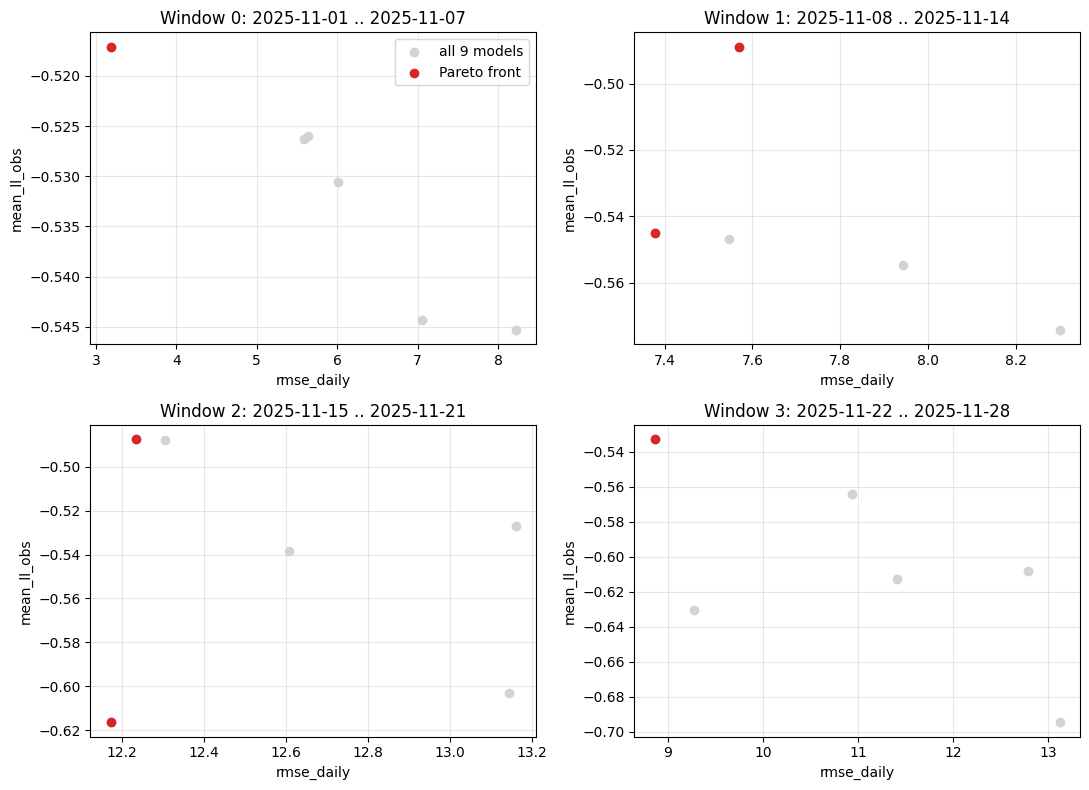

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for window_idx, ax in zip(range(N_WINDOWS), axes.ravel()):
    window_df = lgcp_results_df[lgcp_results_df["window_idx"] == window_idx]
    pareto_df = pareto_tables[window_idx]
    ax.scatter(window_df[minimize_col], window_df[maximize_col], color="lightgray", label="all 9 models", zorder=2)
    ax.scatter(pareto_df[minimize_col], pareto_df[maximize_col], color="tab:red", label="Pareto front", zorder=3)
    ax.set_title(f"Window {window_idx}: {WINDOWS[window_idx][0]} .. {WINDOWS[window_idx][1]}")
    ax.set_xlabel(minimize_col)
    ax.set_ylabel(maximize_col)
    ax.grid(alpha=0.3)
axes.ravel()[0].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "pareto_fronts.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
window_champions = []
for window_idx, pareto_df in pareto_tables.items():
    top = pareto_df.iloc[0]
    window_champions.append({
        "window_idx": window_idx,
        "test_start": WINDOWS[window_idx][0],
        "test_end": WINDOWS[window_idx][1],
        "kernel": top["kernel"],
        "lr": top["lr"],
        maximize_col: top[maximize_col],
        minimize_col: top[minimize_col],
    })

window_champions_df = pd.DataFrame(window_champions).sort_values(maximize_col, ascending=False)
print("Best Pareto-optimal model per window:")
display(window_champions_df)

best_window_row = window_champions_df.iloc[0]
SELECTED_WINDOW_IDX = int(best_window_row["window_idx"])
SELECTED_TEST_START, SELECTED_TEST_END = WINDOWS[SELECTED_WINDOW_IDX]
BEST_LGCP_KERNEL = best_window_row["kernel"]
BEST_LGCP_LR = float(best_window_row["lr"])

print(f"\nSelected window: {SELECTED_WINDOW_IDX} ({SELECTED_TEST_START} .. {SELECTED_TEST_END})")
print(f"Selection rule: highest {maximize_col} among each window's Pareto-optimal points.")
print(f"Winning LGCP combo on this window: kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}")

Best Pareto-optimal model per window:


,window_idx,test_start,test_end,kernel,lr,mean_ll_obs,rmse_daily
2,2,2025-11-15,2025-11-21,weekly,0.001,-0.487338,12.233167
1,1,2025-11-08,2025-11-14,monthly,0.010,-0.488844,7.568671
0,0,2025-11-01,2025-11-07,yearly,0.001,-0.517066,3.182285
3,3,2025-11-22,2025-11-28,yearly,0.010,-0.532660,8.862302



Selected window: 2 (2025-11-15 .. 2025-11-21)
Selection rule: highest mean_ll_obs among each window's Pareto-optimal points.
Winning LGCP combo on this window: kernel=weekly  lr=0.001


## Step 3 — Baseline grid searches on the selected window

Hyperparameter grids, chosen to be standard/justifiable rather than tuned:

- **Last-available Poisson**: no continuous hyperparameters — just its two
  prediction modes (`frozen_train`: freeze at the last training value;
  `one_step_ahead`: use the actual last *observed* value each test day).
- **Window Poisson GLM**: `poisson_alpha` (L2 regularization) over a
  standard log-spaced grid, x `window_size` (autoregressive context length)
  over short/weekly/biweekly (3/7/14 days).
- **GNN**: `hidden_dim` and `num_layers` over typical small-GCN capacities,
  x `lr` over a standard Adam range.

In [9]:
la_cfg = last_avail.load_config(None)
la_cfg["years"] = YEARS
la_cfg["parquet_path"] = str(PROJECT_ROOT / la_cfg["parquet_path"])

la_rows = []
for mode in ["frozen_train", "one_step_ahead"]:
    (_, _, _, _, _, test_y, _, df_la) = last_avail.prepare_data(
        la_cfg["parquet_path"], train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=SELECTED_TEST_START, test_end_date=SELECTED_TEST_END,
        years=YEARS,
    )
    df_la["date"] = pd.to_datetime(df_la["date"])
    train_mask, test_mask = last_avail.make_day_split_masks(
        df=df_la, train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=SELECTED_TEST_START, test_end_date=SELECTED_TEST_END,
    )
    test_dates = df_la.loc[test_mask, "date"].values
    preds = last_avail.build_last_available_predictions(df=df_la, train_mask=train_mask, test_mask=test_mask, mode=mode)
    metrics = evaluate_metrics(test_y, preds, test_dates)
    print(f"[last_available mode={mode}] mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}")
    la_rows.append({"mode": mode, **metrics})

la_results_df = pd.DataFrame(la_rows).sort_values("mean_ll_obs", ascending=False)
la_results_df.to_csv(RESULTS_DIR / "last_available_grid_results.csv", index=False)
display(la_results_df)
best_la = la_results_df.iloc[0]

[last_available mode=frozen_train] mean_ll_obs=-4.9275  rmse_daily=14.6775
[last_available mode=one_step_ahead] mean_ll_obs=-2.1742  rmse_daily=17.7079


,mode,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
1,one_step_ahead,-2.174169,0.329446,1.09198,-52.766270,14.142857,17.707948,-0.205343,0.2
0,frozen_train,-4.927505,0.448980,1.30261,-9.960949,12.000000,14.677485,NaN,0.0


In [10]:
glm_cfg = window_glm.load_config(str(PROJECT_ROOT / "config/14_window_poisson_glm.yaml"))
glm_cfg["years"] = YEARS
glm_cfg["parquet_path"] = str(PROJECT_ROOT / glm_cfg["parquet_path"])

ALPHA_GRID = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
WINDOW_SIZE_GRID = [3, 7, 14]

df_glm_raw = window_glm.load_parquet_years(glm_cfg["parquet_path"], YEARS)
df_glm_raw["date"] = pd.to_datetime(df_glm_raw["date"])

glm_rows = []
for window_size in WINDOW_SIZE_GRID:
    cfg_ws = dict(glm_cfg)
    cfg_ws["window_size"] = window_size
    df_win, feature_cols = window_glm.build_window_dataframe(df_glm_raw, cfg_ws)
    train_mask, test_mask = window_glm.make_split_masks(
        dates=df_win["date"], split_strategy="fixed_test_window",
        train_fraction=cfg_ws["train_fraction"], random_seed=cfg_ws["data_seed"],
        test_start_date=SELECTED_TEST_START, test_end_date=SELECTED_TEST_END,
    )
    X = df_win[feature_cols].values.astype(np.float32)
    y = df_win[cfg_ws["target_col"]].values.astype(np.float32)
    dts = df_win["date"].values
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    test_dates = dts[test_mask]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    for alpha in ALPHA_GRID:
        model = PoissonRegressor(alpha=alpha, max_iter=cfg_ws["max_iter"])
        model.fit(X_train_s, y_train)
        preds = np.clip(model.predict(X_test_s), 0, None)
        metrics = evaluate_metrics(y_test, preds, test_dates)
        print(f"[glm window_size={window_size:2d} alpha={alpha:<8}] mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}")
        glm_rows.append({"window_size": window_size, "poisson_alpha": alpha, **metrics})

glm_results_df = pd.DataFrame(glm_rows).sort_values("mean_ll_obs", ascending=False)
glm_results_df.to_csv(RESULTS_DIR / "glm_grid_results.csv", index=False)
display(glm_results_df.head(10))
best_glm = glm_results_df.iloc[0]

[glm window_size= 3 alpha=0.0001  ] mean_ll_obs=-0.5950  rmse_daily=13.9615
[glm window_size= 3 alpha=0.001   ] mean_ll_obs=-0.5954  rmse_daily=13.9807
[glm window_size= 3 alpha=0.01    ] mean_ll_obs=-0.5987  rmse_daily=14.1213
[glm window_size= 3 alpha=0.1     ] mean_ll_obs=-0.6198  rmse_daily=14.9578
[glm window_size= 3 alpha=1.0     ] mean_ll_obs=-0.6707  rmse_daily=15.1014
[glm window_size= 7 alpha=0.0001  ] mean_ll_obs=-0.5703  rmse_daily=12.7968
[glm window_size= 7 alpha=0.001   ] mean_ll_obs=-0.5705  rmse_daily=12.8007
[glm window_size= 7 alpha=0.01    ] mean_ll_obs=-0.5723  rmse_daily=12.8446
[glm window_size= 7 alpha=0.1     ] mean_ll_obs=-0.5848  rmse_daily=13.1709
[glm window_size= 7 alpha=1.0     ] mean_ll_obs=-0.6328  rmse_daily=14.0584
[glm window_size=14 alpha=0.0001  ] mean_ll_obs=-0.5986  rmse_daily=12.5181
[glm window_size=14 alpha=0.001   ] mean_ll_obs=-0.5988  rmse_daily=12.5278
[glm window_size=14 alpha=0.01    ] mean_ll_obs=-0.6006  rmse_daily=12.6008
[glm window_

,window_size,poisson_alpha,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
5,7,0.0001,-0.570279,0.413527,1.025381,-6.653431,9.907421,12.796794,-0.087137,0.2
6,7,0.0010,-0.570482,0.413593,1.025294,-6.671995,9.919945,12.800745,-0.089567,0.2
7,7,0.0100,-0.572340,0.413071,1.025391,-6.827016,9.991795,12.844603,-0.108122,0.2
8,7,0.1000,-0.584833,0.411241,1.029207,-7.607499,10.415713,13.170851,-0.193850,0.2
0,3,0.0001,-0.595028,0.412945,1.126645,-7.376541,10.040000,13.961536,-0.341449,0.2
1,3,0.0010,-0.595432,0.413424,1.128719,-7.398609,10.059122,13.980729,-0.344374,0.2
10,14,0.0001,-0.598595,0.417060,1.048765,-6.492967,9.713457,12.518121,0.024709,0.2
2,3,0.0100,-0.598739,0.416281,1.144033,-7.580801,10.236513,14.121337,-0.373206,0.2
11,14,0.0010,-0.598827,0.416845,1.048850,-6.515010,9.721257,12.527816,0.022506,0.2
12,14,0.0100,-0.600562,0.415837,1.048882,-6.688351,9.795253,12.600808,0.005695,0.2


In [11]:
gnn_cfg = gnn_mod.load_config(str(PROJECT_ROOT / "config/15_gnn.yaml"))
gnn_cfg["years"] = YEARS
gnn_cfg["parquet_path"] = str(PROJECT_ROOT / gnn_cfg["parquet_path"])

HIDDEN_DIM_GRID = [16, 32, 64]
NUM_LAYERS_GRID = [1, 2, 3]
GNN_LR_GRID = [1e-3, 1e-2]

device = torch.device(gnn_cfg.get("device", "cpu"))

df_gnn = gnn_mod.load_parquet_years(gnn_cfg["parquet_path"], YEARS)
df_gnn["date"] = pd.to_datetime(df_gnn["date"])
df_feat, feature_cols = gnn_mod.build_node_features(df_gnn, gnn_cfg)
X, Y, dates, cell_coords = gnn_mod.build_graph_tensors(df_feat, feature_cols, gnn_cfg["target_col"])
n_dates, n_cells, n_features = X.shape

adj = gnn_mod.build_grid_adjacency(
    cell_coords[["longitude", "latitude"]].to_numpy(), connectivity=gnn_cfg.get("adjacency", "queen")
)
adj_norm = gnn_mod.normalize_adjacency(adj)
adj_norm_t = torch.tensor(adj_norm, dtype=torch.float32, device=device)

train_mask, test_mask = gnn_mod.make_day_split_masks(
    df=pd.DataFrame({"date": dates}), train_fraction=gnn_cfg["train_fraction"], random_seed=gnn_cfg["data_seed"],
    split_strategy="fixed_test_window", test_start_date=SELECTED_TEST_START, test_end_date=SELECTED_TEST_END,
)
X_train, Y_train = X[train_mask], Y[train_mask]
X_test, Y_test = X[test_mask], Y[test_mask]
dates_test = dates[test_mask]

scaler = StandardScaler()
scaler.fit(X_train.reshape(-1, n_features))
X_train_model = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
X_test_model = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

X_train_t = torch.tensor(X_train_model, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_test_t = torch.tensor(X_test_model, dtype=torch.float32, device=device)

gnn_rows = []
for hidden_dim, num_layers, lr in itertools.product(HIDDEN_DIM_GRID, NUM_LAYERS_GRID, GNN_LR_GRID):
    torch.manual_seed(SEED)
    model = gnn_mod.SpatioTemporalGNN(
        in_dim=n_features, hidden_dim=hidden_dim, num_layers=num_layers, dropout=gnn_cfg["dropout"],
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=gnn_cfg["weight_decay"])

    model.train()
    for epoch in range(1, int(gnn_cfg["num_epochs"]) + 1):
        optimizer.zero_grad()
        rate_train = model(X_train_t, adj_norm_t)
        loss = gnn_mod.poisson_nll(rate_train, Y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        rate_test = model(X_test_t, adj_norm_t).cpu().numpy()
    rate_test = np.clip(rate_test, 0, None)

    y_test_flat = Y_test.reshape(-1)
    rate_test_flat = rate_test.reshape(-1)
    test_dates_flat = np.repeat(dates_test, n_cells)
    metrics = evaluate_metrics(y_test_flat, rate_test_flat, test_dates_flat)

    print(
        f"[gnn hidden_dim={hidden_dim:2d} num_layers={num_layers} lr={lr:<6}] "
        f"mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}"
    )
    gnn_rows.append({"hidden_dim": hidden_dim, "num_layers": num_layers, "lr": lr, **metrics})

gnn_results_df = pd.DataFrame(gnn_rows).sort_values("mean_ll_obs", ascending=False)
gnn_results_df.to_csv(RESULTS_DIR / "gnn_grid_results.csv", index=False)
display(gnn_results_df.head(10))
best_gnn = gnn_results_df.iloc[0]

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
[gnn hidden_dim=16 num_layers=1 lr=0.001 ] mean_ll_obs=-0.6231  rmse_daily=11.8839
[gnn hidden_dim=16 num_layers=1 lr=0.01  ] mean_ll_obs=-0.5741  rmse_daily=12.2450
[gnn hidden_dim=16 num_layers=2 lr=0.001 ] mean_ll_obs=-0.5986  rmse_daily=11.6897
[gnn hidden_dim=16 num_layers=2 lr=0.01  ] mean_ll_obs=-0.4898  rmse_daily=11.3253
[gnn hidden_dim=16 num_layers=3 lr=0.001 ] mean_ll_obs=-0.6221  rmse_daily=11.6725
[gnn hidden_dim=16 num_layers=3 lr=0.01  ] mean_ll_obs=-0.5881  rmse_daily=12.4796
[gnn hidden_dim=32 num_layers=1 lr=0.001 ] mean_ll_obs=-0.6253  rmse_daily=11.8776
[gnn hidden_dim=32 num_layers=1 lr=0.01  ] mean_ll_obs=-0.5283  rmse_daily=11.8730
[gnn hidden_dim=32 num_layers=2 lr=0.001 ] mean_ll_obs=-0.5893  rmse_daily=11.6035
[gnn hidden_dim=32 num_layers=2 lr=0.01  ] mean_ll_obs=-0.4795  rmse_daily=11.3446
[gnn hidden_dim=32 num_layer

,hidden_dim,num_layers,lr,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
15,64,2,0.010,-0.456036,0.335242,0.935857,-5.297519,8.830774,10.673492,0.630686,0.8
9,32,2,0.010,-0.479473,0.339782,0.970775,-5.570395,9.491560,11.344645,0.524229,1.0
3,16,2,0.010,-0.489775,0.350832,0.943492,-5.723006,8.872254,11.325265,0.356447,0.6
13,64,1,0.010,-0.514978,0.347393,1.022030,-5.909996,9.243835,12.076877,0.337258,0.6
7,32,1,0.010,-0.528291,0.359950,1.007620,-6.132563,8.807147,11.873010,0.289789,0.6
11,32,3,0.010,-0.546591,0.368389,1.034756,-5.946473,8.064567,11.547767,0.306302,0.4
17,64,3,0.010,-0.567398,0.349687,1.001078,-6.306283,8.708117,10.881330,0.673270,0.8
1,16,1,0.010,-0.574064,0.379128,1.040125,-6.468958,9.030295,12.245028,0.143559,0.4
14,64,2,0.001,-0.579970,0.400261,1.044428,-5.467433,9.159739,11.252292,0.430051,0.6
5,16,3,0.010,-0.588070,0.397083,1.074473,-6.128982,10.116760,12.479552,0.421797,0.8


## Step 4 — Confirm the winning LGCP configuration at full training length

The 36-run search above used a reduced `NUM_STEPS` budget. The winning
(window, kernel, lr) combination is re-trained here at `NUM_STEPS_FINAL`
(the "standard" length from `train_basic_lgcp_multi_kernel.yaml`) so its
row in the final table is trained to the same standard as it would be for
any other individual run.

In [12]:
sel_data = WINDOW_DATA[SELECTED_WINDOW_IDX]
best_period_std = period_to_std(PERIOD_SPECS[BEST_LGCP_KERNEL], sel_data["t_scaler"], sel_data["span_days"])
best_model_cfg = build_temporal_model_cfg(base_cfg["model"], best_period_std)

print(f"Confirming winner on window {SELECTED_WINDOW_IDX} ({SELECTED_TEST_START} .. {SELECTED_TEST_END})")
print(f"  kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_steps={NUM_STEPS_FINAL}")

lgcp_best_metrics, lgcp_best_elapsed = run_lgcp_combo(
    base_cfg,
    sel_data["train_coords"], sel_data["train_covs"], sel_data["train_y"],
    sel_data["test_coords"], sel_data["test_covs"], sel_data["test_y"], sel_data["test_dates"],
    lr=BEST_LGCP_LR, num_mc=NUM_MC, num_steps=NUM_STEPS_FINAL, model_cfg=best_model_cfg, seed=SEED,
)
if lgcp_best_metrics["failed"]:
    raise RuntimeError(
        "The winning LGCP config failed to converge on the full-length confirm run "
        "(it succeeded during the shorter search). Re-run this cell (different MC "
        "noise may avoid it) or pick the runner-up combo from window_champions_df."
    )

print(f"\nConfirmed LGCP metrics ({lgcp_best_elapsed:.1f}s):")
for k in METRIC_KEYS:
    print(f"  {k}: {lgcp_best_metrics[k]:.4f}")

Confirming winner on window 2 (2025-11-15 .. 2025-11-21)
  kernel=weekly  lr=0.001  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=28309.5117  ll=-862.6472  kl=74.6649  (0.1s)
[  5000/5000]  loss=13821.9883  ll=-409.6493  kl=413.9734  (237.9s)

Confirmed LGCP metrics (237.9s):
  mean_ll_obs: -0.5378
  mae_obs: 0.3512
  rmse_obs: 1.0485
  mean_ll_daily: -6.4633
  mae_daily: 9.0139
  rmse_daily: 12.6523
  daily_delta_corr: 0.2579
  daily_direction_accuracy_moving: 0.4000


## Final comparison table

In [13]:
metric_keys = METRIC_KEYS

final_rows = [
    {
        "method": "LGCP",
        "hyperparameters": f"kernel={BEST_LGCP_KERNEL}, lr={BEST_LGCP_LR}, num_mc={NUM_MC}, num_steps={NUM_STEPS_FINAL}",
        **{k: lgcp_best_metrics[k] for k in metric_keys},
    },
    {
        "method": "Window Poisson GLM",
        "hyperparameters": f"window_size={int(best_glm['window_size'])}, poisson_alpha={best_glm['poisson_alpha']}",
        **{k: best_glm[k] for k in metric_keys},
    },
    {
        "method": "GNN",
        "hyperparameters": f"hidden_dim={int(best_gnn['hidden_dim'])}, num_layers={int(best_gnn['num_layers'])}, lr={best_gnn['lr']}",
        **{k: best_gnn[k] for k in metric_keys},
    },
    {
        "method": "Last Available Poisson",
        "hyperparameters": f"mode={best_la['mode']}",
        **{k: best_la[k] for k in metric_keys},
    },
]

final_df = pd.DataFrame(final_rows).set_index("method")
final_df.to_csv(RESULTS_DIR / "final_comparison_table.csv")

print(f"Test window used for every method: {SELECTED_TEST_START} .. {SELECTED_TEST_END}")
print(f"All intermediate results + this table saved under: {RESULTS_DIR}\n")
final_df

Test window used for every method: 2025-11-15 .. 2025-11-21
All intermediate results + this table saved under: /home/samuele/projects/AIPS/reports/paper/lgcp_pareto_2025_11



,hyperparameters,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,,
LGCP,"kernel=weekly, lr=0.001, num_mc=32, num_steps=...",-0.537846,0.351234,1.048452,-6.463317,9.013935,12.652317,0.257881,0.4
Window Poisson GLM,"window_size=7, poisson_alpha=0.0001",-0.570279,0.413527,1.025381,-6.653431,9.907421,12.796794,-0.087137,0.2
GNN,"hidden_dim=64, num_layers=2, lr=0.01",-0.456036,0.335242,0.935857,-5.297519,8.830774,10.673492,0.630686,0.8
Last Available Poisson,mode=one_step_ahead,-2.174169,0.329446,1.091980,-52.766270,14.142857,17.707948,-0.205343,0.2


**Notes for the paper writeup**

- All 4 methods are evaluated on the identical test window
  (`SELECTED_TEST_START..SELECTED_TEST_END`), trained on the identical
  `years=[2024, 2025]` data available before that window.
- The LGCP row was chosen via a Pareto front over `(mean_ll_obs, rmse_daily)`
  across 36 (window x kernel x lr) runs, then re-trained at full length.
- Each baseline's row is its best grid-search configuration, ranked by
  `mean_ll_obs`, over a standard/justifiable hyperparameter range (see the
  markdown cell above Step 3).
- Intermediate leaderboards (`lgcp_grid_results.csv`, `glm_grid_results.csv`,
  `gnn_grid_results.csv`, `last_available_grid_results.csv`) and the Pareto
  front figure are saved alongside the final table for supplementary
  material / reproducibility.